# ⬇️ | Imports

In [14]:
import os
import shutil
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support




2 . 

In [15]:
X_train = pd.read_csv("../X_train.csv")
y_train = pd.read_csv("../y_train.csv")["target"]

X_val = pd.read_csv("../X_val.csv")
y_val = pd.read_csv("../y_val.csv")["target"]

X_test = pd.read_csv("../X_test.csv")
y_test = pd.read_csv("../y_test.csv")["target"]

print("Treino:", X_train.shape)

print("Validação:", X_val.shape)

print("Teste:", X_test.shape)

Treino: (9234, 23)
Validação: (1635, 23)
Teste: (2688, 23)


3.

In [16]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

print(" Dados normalizados com StandardScaler com sucesso!")

 Dados normalizados com StandardScaler com sucesso!


4.

In [17]:
# random forest

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)


y_val_pred_rf = rf_model.predict(X_val_scaled)
acc_val_rf = accuracy_score(y_val, y_val_pred_rf)

print("✓ Random Forest treinado com sucesso!")
print(f" Acurácia obtida na Validação: {acc_val_rf * 100:.2f}%")

✓ Random Forest treinado com sucesso!
 Acurácia obtida na Validação: 99.08%


5.

In [18]:
# svm

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)


y_val_pred_svm = svm_model.predict(X_val_scaled)
acc_val_svm = accuracy_score(y_val, y_val_pred_svm)

print("✓ SVM treinado com sucesso!")
print(f"Acurácia obtida na Validação: {acc_val_svm * 100:.2f}%")

✓ SVM treinado com sucesso!
Acurácia obtida na Validação: 93.27%


7.

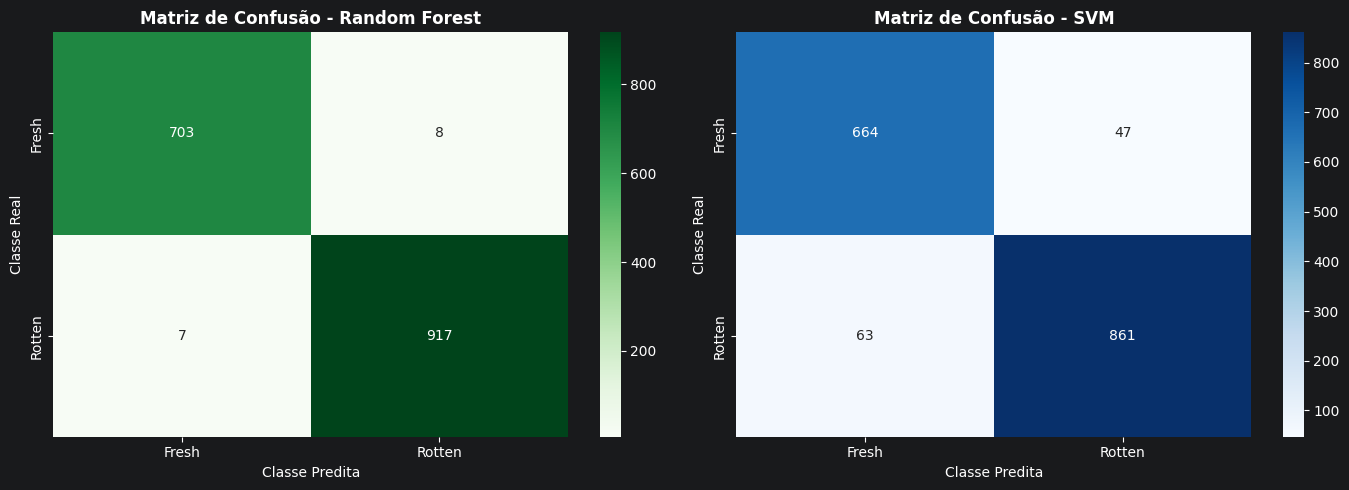

Painel visual das matrizes: ../outputs/matrizes_confusao_comparadas.png


In [19]:
cm_rf = confusion_matrix(y_val, y_val_pred_rf)
cm_svm = confusion_matrix(y_val, y_val_pred_svm)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", ax=axes[0],
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
axes[0].set_title("Matriz de Confusão - Random Forest", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Classe Real")
axes[0].set_xlabel("Classe Predita")

sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=svm_model.classes_, yticklabels=svm_model.classes_)
axes[1].set_title("Matriz de Confusão - SVM", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Classe Real")
axes[1].set_xlabel("Classe Predita")

plt.tight_layout()
caminho_matrizes = "../outputs/matrizes_confusao_comparadas.png"
plt.savefig(caminho_matrizes, dpi=300)
plt.show()

print(f"Painel visual das matrizes: {caminho_matrizes}")

8.

In [20]:
def extrair_metricas(y_true, y_pred, acc):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    return {
        "Accuracy": round(acc, 4),
        "Precision": round(p, 4),
        "Recall": round(r, 4),
        "F1": round(f1, 4)
    }


dados_rf = extrair_metricas(y_val, y_val_pred_rf, acc_val_rf)
dados_svm = extrair_metricas(y_val, y_val_pred_svm, acc_val_svm)


tabela_final = pd.DataFrame([dados_rf, dados_svm], index=["Random Forest", "SVM"])

print("TABELA COMPARATIVA FINAL")
display(tabela_final)

caminho_tabela = "../outputs/tabela_comparativa_modelos.csv"
tabela_final.to_csv(caminho_tabela, index=True)
print(f" Arquivo CSV salvo: {caminho_tabela}")

TABELA COMPARATIVA FINAL


,Accuracy,Precision,Recall,F1
Random Forest,0.9908,0.9907,0.9906,0.9907
SVM,0.9327,0.9308,0.9329,0.9317


 Arquivo CSV salvo: ../outputs/tabela_comparativa_modelos.csv


9.

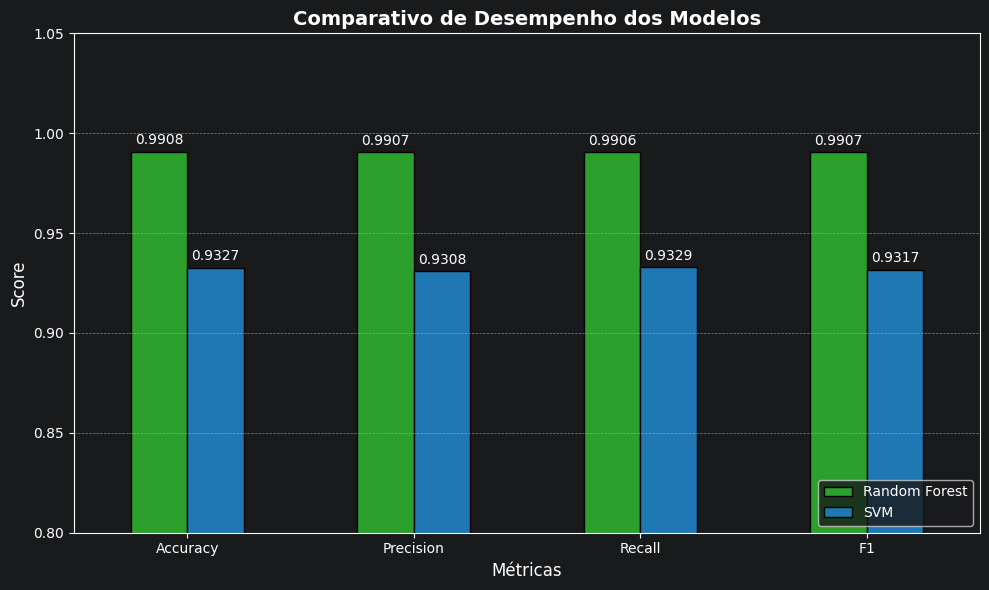


 DESEMPENHO NO CONJUNTO DE TESTE ISOLADO (AVALIAÇÃO FINAL
 Random Forest - Acurácia Final: 99.52%
 SVM           - Acurácia Final: 94.57%


In [21]:

tabela_plot = tabela_final.T
ax = tabela_plot.plot(kind="bar", figsize=(10, 6), color=["#2ca02c", "#1f77b4"], edgecolor="black")

plt.title("Comparativo de Desempenho dos Modelos", fontsize=14, fontweight='bold')
plt.xlabel("Métricas", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0.8, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.legend(loc="lower right")

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3)

plt.tight_layout()
caminho_grafico = "../outputs/grafico_comparativo_modelos.png"
plt.savefig(caminho_grafico, dpi=300)
plt.show()


y_test_pred_rf = rf_model.predict(X_test_scaled)
y_test_pred_svm = svm_model.predict(X_test_scaled)

print("\n DESEMPENHO NO CONJUNTO DE TESTE ISOLADO (AVALIAÇÃO FINAL")
print(f" Random Forest - Acurácia Final: {accuracy_score(y_test, y_test_pred_rf) * 100:.2f}%")
print(f" SVM           - Acurácia Final: {accuracy_score(y_test, y_test_pred_svm) * 100:.2f}%")

10.

In [22]:
from pathlib import Path
import pandas as pd
import shutil
import os
import numpy as np

PASTA_ERROS = Path("../outputs/imagens_de_erros")

os.makedirs(PASTA_ERROS,exist_ok=True)

val_paths = pd.read_csv("../val_paths.csv")["path"]

reais = np.array(y_val)
preditos = np.array(y_val_pred_rf)

indices_erros = np.where(reais != preditos)[0]

print(f"Total de erros: {len(indices_erros)}")

for idx in indices_erros[:10]:

    origem = Path(
        val_paths.iloc[idx]
    )
    nome = (
        f"Real_{reais[idx]}"
        f"_Predito_{preditos[idx]}"
        f"_{origem.name}"
    )

    destino = (PASTA_ERROS/ nome)
    shutil.copy(origem,destino)



Total de erros: 15


In [23]:
print()

print("VALIDAÇÃO")
print("----------------")

print(
    "RF:",
    round(
        accuracy_score(
            y_val,
            y_val_pred_rf
        ),
        4
    )
)

print(
    "SVM:",
    round(
        accuracy_score(
            y_val,
            y_val_pred_svm
        ),
        4
    )
)

print()

print("TESTE FINAL")
print("----------------")

print(
    "RF:",
    round(
        accuracy_score(
            y_test,
            y_test_pred_rf
        ),
        4
    )
)

print(
    "SVM:",
    round(
        accuracy_score(
            y_test,
            y_test_pred_svm
        ),
        4
    )
)


VALIDAÇÃO
----------------
RF: 0.9908
SVM: 0.9327

TESTE FINAL
----------------
RF: 0.9952
SVM: 0.9457


In [24]:
print(
    pd.merge(
        X_train,
        X_test,
        how="inner"
    ).shape
)

(3, 23)


In [25]:
print()

print("Train")
print(y_train.value_counts())

print()

print("Val")
print(y_val.value_counts())

print()

print("Test")
print(y_test.value_counts())


Train
target
Rotten    5211
Fresh     4023
Name: count, dtype: int64

Val
target
Rotten    924
Fresh     711
Name: count, dtype: int64

Test
target
Rotten    1526
Fresh     1162
Name: count, dtype: int64


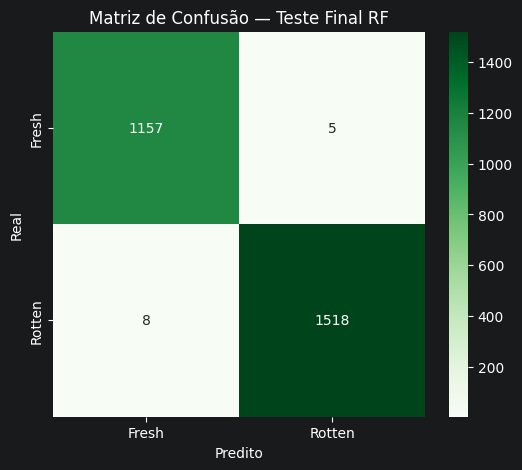

In [26]:
cm_rf_test = confusion_matrix(
    y_test,
    y_test_pred_rf
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf_test,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=rf_model.classes_,
    yticklabels=rf_model.classes_
)

plt.title(
    "Matriz de Confusão — Teste Final RF"
)

plt.xlabel(
    "Predito"
)

plt.ylabel(
    "Real"
)

plt.show()